In [3]:
import xarray as xr
import numpy as np

In [12]:
imerg_recent = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20210614_20220731.nc')
imerg_recent

<xarray.Dataset> Size: 98GB
Dimensions:                  (time: 1649, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 13kB 2021-06-14T12:00:00 ....
  * longitude                (longitude) float32 1kB -180.0 -179.0 ... 179.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 430MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 430MB ...
    2m_temperature           (time, latitude, longitude) float32 430MB ...
    geopotential             (time, level, latitude, longitude) float32 16GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 16GB ...
    temperature              (time, level, latitude, longitude) float32 16GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 16GB ...
    total_precipitation_6hr  (time, latitude, longitude) float64 860MB ...

In [18]:
ds_out = imerg_recent.copy()

In [19]:
# Shift longitudes into [0, 360)
ds_out = ds_out.assign_coords({ 
    'longitude': ( (ds_out['longitude'] + 180) )
})

# Sort along the longitude axis
ds_out = ds_out.sortby('longitude')
ds_out

<xarray.Dataset> Size: 98GB
Dimensions:                  (time: 1649, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 13kB 2021-06-14T12:00:00 ....
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 430MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 430MB ...
    2m_temperature           (time, latitude, longitude) float32 430MB ...
    geopotential             (time, level, latitude, longitude) float32 16GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 16GB ...
    temperature              (time, level, latitude, longitude) float32 16GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 16GB ...
    total_precipitation_6hr  (time, latitude, longitude) float64 860MB ...

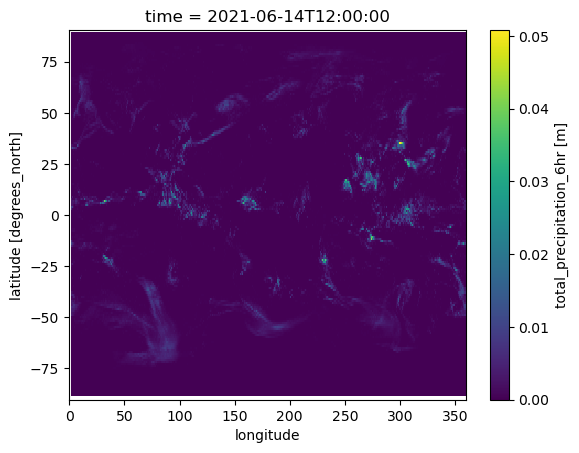

In [20]:
ds_out.isel(time=0)['total_precipitation_6hr'].plot()

In [ ]:
ds_transformed

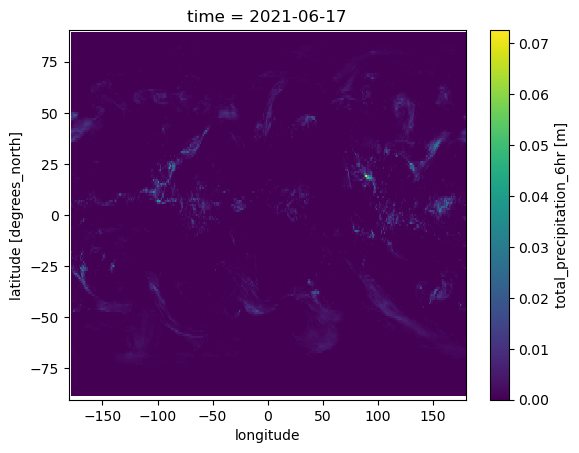

In [39]:
imerg_recent.isel(time=10)['total_precipitation_6hr'].plot()

In [7]:
ds = imerg_recent.copy()
ds

<xarray.Dataset> Size: 98GB
Dimensions:                  (time: 1649, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 13kB 2021-06-14T12:00:00 ....
  * longitude                (longitude) float32 1kB -180.0 -179.0 ... 179.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 430MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 430MB ...
    2m_temperature           (time, latitude, longitude) float32 430MB ...
    geopotential             (time, level, latitude, longitude) float32 16GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 16GB ...
    temperature              (time, level, latitude, longitude) float32 16GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 16GB ...
    total_precipitation_6hr  (time, latitude, longitude) float64 860MB ...

In [8]:
ds['longitude']

<xarray.DataArray 'longitude' (longitude: 360)> Size: 1kB
array([-180., -179., -178., ...,  177.,  178.,  179.], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0

In [9]:
# 1) wrap into [0,360)
wrapped = (ds['longitude'] + 360) % 360
ds = ds.assign_coords({'longitude': wrapped})

# 2) sort by the new longitude values
ds = ds.sortby('longitude')

# 3) drop any duplicate longitudegitudes (e.g. both -180→180 and +180→180)
#    keep the *first* occurrence of each unique longitude
unique_vals, first_idx = np.unique(ds['longitude'].values, return_index=True)
ds = ds.isel({'longitude': first_idx})


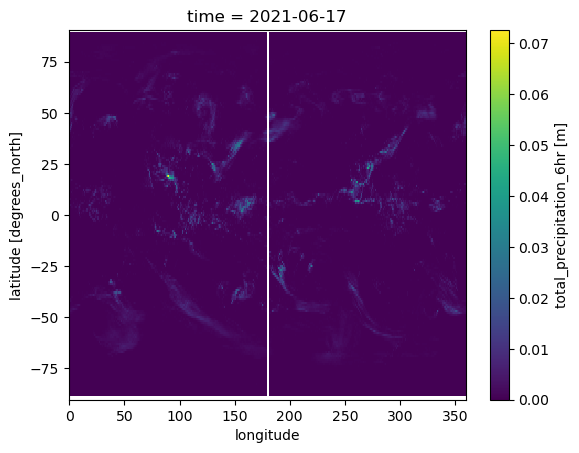

In [11]:
ds.isel(time=10)['total_precipitation_6hr'].plot()

In [11]:
imerg_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20240929-S000000-E235959.V07B.nc4")
imerg_test

<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
  * time                            (time) datetime64[ns] 8B 2024-09-29
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB ...
    time_bnds                       (time, nv) datetime64[ns] 16B ...
Attributes:
    BeginDate:       2024-09-29
    BeginTime:       00:00:00.000Z
    EndDate:         2024-09-29
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-09-29T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240929-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2025-01-28T21:50:39.390Z

In [ ]:
# flip the order of the lat lon dimensions

In [ ]:
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

# imerg_india = imerg_test.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
# imerg_india['precipitation']

<xarray.DataArray 'precipitation' (time: 1, lon: 300, lat: 320)> Size: 384kB
[96000 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 1kB 68.05 68.15 68.25 68.35 ... 97.75 97.85 97.95
  * lat      (lat) float64 3kB 6.05 6.15 6.25 6.35 ... 37.65 37.75 37.85 37.95
  * time     (time) datetime64[ns] 8B 2024-09-29
Attributes:
    units:      mm/day
    long_name:  Daily mean precipitation rate (combined microwave-IR) estimat...

In [12]:
old_lats = imerg_test['lat'].values
old_lons = imerg_test['lon'].values
new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
new_lats = np.flip(new_lats)
new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
imerg_test_interp = imerg_test.interp({'lat': new_lats, 'lon': new_lons}, 
                        method='linear',
                        kwargs={'fill_value': None})
imerg_test_interp

<xarray.Dataset> Size: 5MB
Dimensions:                         (time: 1, lon: 360, lat: 181, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2024-09-29
  * lat                             (lat) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * lon                             (lon) float64 3kB 0.0 1.0 ... 358.0 359.0
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float64 521kB nan ... nan
    precipitation_cnt               (time, lon, lat) float64 521kB nan ... nan
    precipitation_cnt_cond          (time, lon, lat) float64 521kB nan ... nan
    MWprecipitation                 (time, lon, lat) float64 521kB nan ... nan
    MWprecipitation_cnt             (time, lon, lat) float64 521kB nan ... nan
    MWprecipitation_cnt_cond        (time, lon, lat) float64 521kB nan ... nan
    randomError                     (time, lon, lat) float64 521kB nan ... nan
    randomError_cnt                 (time, lon, lat) float64 521kB nan ... nan
    probabilityLiquidPrecipitation  (time, lon, lat) float64 521kB nan ... nan
    time_bnds                       (time, nv) datetime64[ns] 16B 2024-09-29 ...
Attributes:
    BeginDate:       2024-09-29
    BeginTime:       00:00:00.000Z
    EndDate:         2024-09-29
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-09-29T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240929-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2025-01-28T21:50:39.390Z

In [ ]:
import glob
from tqdm import tqdm

files = sorted(glob.glob('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/*.nc4'))

data_list = []


numfiles = 3369
for fname in tqdm(files):
    i = 0
    if i >= numfiles-2:
        break
    try:
        ds = xr.open_dataset(fname)
        old_lats = imerg_test['lat'].values
old_lons = imerg_test['lon'].values
new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
new_lats = np.flip(new_lats)
new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
imerg_test_interp = imerg_test.interp({'lat': new_lats, 'lon': new_lons}, 
                        method='linear',
                        kwargs={'fill_value': None})

    except OSError as ose:
        print(f"Error opening file {fname}: {ose}")
        continue
    try:
        ds_subset = ds[['precipitation', 'randomError']]
    except KeyError as ke:
        raise KeyError(f"File {fname} is missing one of the required variables: {ke}")
    data_list.append(ds_subset)
    i += 1

combined = xr.concat(data_list, dim='time')

100%|██████████| 3369/3369 [00:20<00:00, 165.99it/s]


In [39]:
# return index of the file that has the string 20150601
def get_index_of_file_with_date(files, date_str):
    for i, file in enumerate(files):
        if date_str in file:
            return i
    return -1
# get the index of the file that has the string 20150601
index = get_index_of_file_with_date(files, '20200520')
index

1776

In [50]:

import glob
from tqdm import tqdm
files = sorted(glob.glob('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/*.nc4'))

combined = None  # Initialize the combined dataset

numfiles = 3369
for i, fname in enumerate(tqdm(files)):
    if i >= numfiles - 2:
        break
    try:
        ds = xr.open_dataset(fname)
        old_lats = ds['lat'].values
        old_lons = ds['lon'].values
        new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
        new_lats = np.flip(new_lats)
        new_lons = np.arange(-180.0, 180.0 + 1e-8, 1.0)
        ds_interp = ds.interp({'lat': new_lats, 'lon': new_lons}, 
                                method='linear',
                                kwargs={'fill_value': None})
    except OSError as ose:
        print(f"Error opening file {fname}: {ose}")
        continue
    try:
        ds_subset = ds_interp[['precipitation', 'randomError']]
    except KeyError as ke:
        raise KeyError(f"File {fname} is missing one of the required variables: {ke}")
    
    # Concatenate step by step
    if combined is None:
        combined = ds_subset
    else:
        combined = xr.concat([combined, ds_subset], dim='time')

100%|█████████▉| 3367/3369 [47:48<00:01,  1.17it/s]


In [74]:
combined

<xarray.Dataset> Size: 4GB
Dimensions:        (time: 3367, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 27kB 2015-07-01 ... 2024-09-27
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 2GB ...
    randomError    (time, lon, lat) float64 2GB ...
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

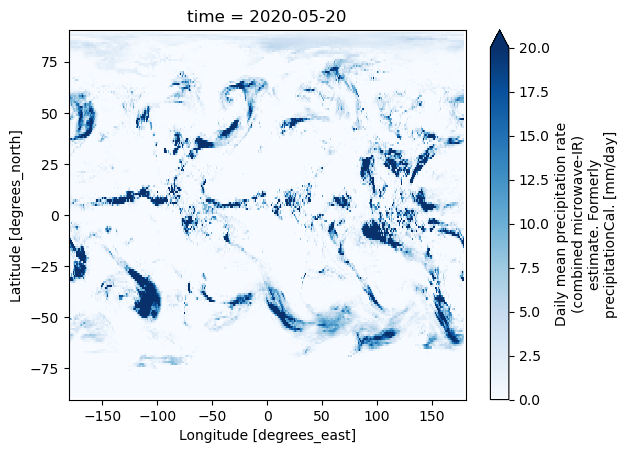

In [1]:
import xarray as xr
combined = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_20150701_20240929.nc4')
combined.sel(time='2020-05-20').precipitation.plot(x='lon', y='lat', cmap='Blues', vmin=0, vmax=20)

In [4]:
import xarray as xr
era5_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_2015_2022-07-31T18_1deg_37levels.nc")
era5_test

<xarray.Dataset> Size: 655GB
Dimensions:                  (time: 11076, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 89kB 2015-01-01 ... 2022-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 3GB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 3GB ...
    2m_temperature           (time, latitude, longitude) float32 3GB ...
    geopotential             (time, level, latitude, longitude) float32 107GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 107GB ...
    temperature              (time, level, latitude, longitude) float32 107GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 3GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 107GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 107GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 107GB ...

In [5]:
combined=xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_20150701_20240929.nc4')

In [3]:
combined

<xarray.Dataset> Size: 4GB
Dimensions:        (time: 3367, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 27kB 2015-07-01 ... 2024-09-27
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 2GB ...
    randomError    (time, lon, lat) float64 2GB ...
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

In [2]:
import xarray as xr
import numpy as np
india_imerg = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india.nc")
india_imerg

<xarray.Dataset> Size: 687MB
Dimensions:                  (time: 736, latitude: 33, longitude: 31, level: 37)
Coordinates:
  * latitude                 (latitude) float32 132B 6.0 7.0 8.0 ... 37.0 38.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 6kB 2015-07-01 ... 2015-12...
  * longitude                (longitude) float32 124B 68.0 69.0 ... 97.0 98.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 3MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 3MB ...
    2m_temperature           (time, latitude, longitude) float32 3MB ...
    geopotential             (time, level, latitude, longitude) float32 111MB ...
    geopotential_at_surface  (latitude, longitude) float32 4kB ...
    land_sea_mask            (latitude, longitude) float32 4kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 111MB ...
    temperature              (time, level, latitude, longitude) float32 111MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 111MB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 111MB ...
    vertical_velocity        (time, level, latitude, longitude) float32 111MB ...
    total_precipitation_6hr  (time, latitude, longitude) float64 6MB ...

In [7]:
imerg_sub = combined.sel(time=slice('2015-07-01', '2022-07-30'))
era5_sub = era5_test.sel(time=slice('2015-07-01', None))
era5_sub

<xarray.Dataset> Size: 612GB
Dimensions:                  (time: 10352, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 83kB 2015-07-01 ... 2022-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 3GB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 3GB ...
    2m_temperature           (time, latitude, longitude) float32 3GB ...
    geopotential             (time, level, latitude, longitude) float32 100GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 100GB ...
    temperature              (time, level, latitude, longitude) float32 100GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 3GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 100GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 100GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 100GB ...

In [8]:
era5_sub.isel(time=0)['total_precipitation_6hr']

<xarray.DataArray 'total_precipitation_6hr' (latitude: 181, longitude: 360)> Size: 261kB
[65160 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    time       datetime64[ns] 8B 2015-07-01
Attributes:
    long_name:   Total precipitation
    short_name:  tp
    units:       m

In [9]:
from datetime import timedelta
import pandas as pd
import numpy as np
from tqdm import tqdm


# Load datasets (assuming they're already in memory as described)
# era5_sub = xr.open_dataset('path_to_era5.nc')
# imerg2015 = xr.open_dataset('path_to_imerg.nc')

# First, let's align the spatial coordinates
# IMERG: lat [-90, 90], lon [-180, 180]
# ERA5: lat [-90, 90], lon [0, 359]

# Convert ERA5 longitudes from [0, 359] to [-180, 179] to match IMERG
era5_sub = era5_sub.assign_coords(longitude=(((era5_sub.longitude + 180) % 360) - 180))
era5_sub = era5_sub.sortby("longitude")
era5_sub

<xarray.Dataset> Size: 612GB
Dimensions:                  (time: 10352, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 83kB 2015-07-01 ... 2022-0...
  * longitude                (longitude) float32 1kB -180.0 -179.0 ... 179.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 3GB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 3GB ...
    2m_temperature           (time, latitude, longitude) float32 3GB ...
    geopotential             (time, level, latitude, longitude) float32 100GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 100GB ...
    temperature              (time, level, latitude, longitude) float32 100GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 3GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 100GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 100GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 100GB ...

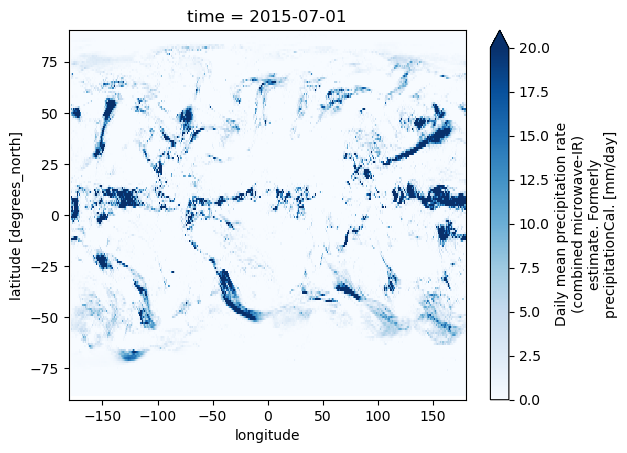

In [10]:
# Interpolate IMERG data to ERA5 grid
# First, we create the target grid coordinates
target_lat = era5_sub.latitude
target_lon = era5_sub.longitude

# Interpolate IMERG to ERA5 spatial grid
imerg_regridded = imerg_sub.interp(lat=target_lat, lon=target_lon)
imerg_regridded.isel(time=0)['precipitation'].plot(x='longitude', y='latitude', cmap='Blues', vmin=0, vmax=20)

In [11]:

# Now we need to address the temporal difference:
# 1. ERA5 has 6-hourly data (4 points per day)
# 2. IMERG has daily data
# We'll distribute the daily IMERG data evenly across the 4 6-hourly periods

# Create an empty dataset for our converted IMERG data with ERA5's time dimension
era5_times = era5_sub.time
imerg_6hr = xr.Dataset(
    data_vars={
        "precipitation_6hr": (("time", "latitude", "longitude"), 
                            np.zeros((len(era5_times), len(target_lat), len(target_lon))))
    },
    coords={
        "time": era5_times,
        "longitude": target_lon,
        "latitude": target_lat
    }
)
imerg_6hr

<xarray.Dataset> Size: 5GB
Dimensions:            (time: 10352, latitude: 181, longitude: 360)
Coordinates:
  * time               (time) datetime64[ns] 83kB 2015-07-01 ... 2022-07-31T1...
  * longitude          (longitude) float32 1kB -180.0 -179.0 ... 178.0 179.0
  * latitude           (latitude) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
Data variables:
    precipitation_6hr  (time, latitude, longitude) float64 5GB 0.0 0.0 ... 0.0

In [181]:
first  = pd.DatetimeIndex(era5_times.values).normalize().unique()[0]
first

Timestamp('2015-07-01 00:00:00')

In [182]:
next_day = first + pd.Timedelta(days=1)
next_day

Timestamp('2015-07-02 00:00:00')

In [184]:
imerg_regridded.sel(time=first)

<xarray.Dataset> Size: 1MB
Dimensions:        (longitude: 360, latitude: 181)
Coordinates:
    time           datetime64[ns] 8B 2015-07-01
    lat            (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
    lon            (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude       (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * longitude      (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    precipitation  (longitude, latitude) float64 521kB nan nan nan ... 0.0 nan
    randomError    (longitude, latitude) float64 521kB nan nan nan ... 2.765 nan
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

In [42]:
imerg_regridded.sel(time='2018-04-01')

<xarray.Dataset> Size: 1MB
Dimensions:        (longitude: 360, latitude: 181)
Coordinates:
    time           datetime64[ns] 8B 2018-04-01
    lat            (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
    lon            (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude       (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * longitude      (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    precipitation  (longitude, latitude) float64 521kB nan nan nan ... 0.0 nan
    randomError    (longitude, latitude) float64 521kB nan nan nan ... 2.765 nan
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

In [12]:
# Loop through each unique day in ERA5 data
for day in tqdm(pd.DatetimeIndex(era5_times.values).normalize().unique()):
    # Get day's end (exclusive)
    next_day = day + pd.Timedelta(days=1)

    # print(f"Processing day: {day}")
    
    # Find the corresponding IMERG data for this day
    # if the imerg data is not available for this day, skip and fill in the previous day values for this day
    try:
        imerg_day_data = imerg_regridded.sel(time=day)
    except KeyError:
        print(f"Warning: No IMERG data for {day}")
        try:
            imerg_day_data = imerg_regridded.sel(time=day+pd.Timedelta(days=1))
        except KeyError:
            print(f"Warning: No IMERG data for {day+pd.Timedelta(days=1)}")
            # Fill with NaN or some other placeholder
            imerg_day_data = imerg_regridded.sel(time=day-pd.Timedelta(days=1))
            continue
        continue


    
    if 'precipitation' not in imerg_day_data:
        print(f"Warning: No IMERG data for {day}")
        continue
    
    # Get precipitation rate (mm/day)
    daily_precip_rate = imerg_day_data.precipitation
    
    # UNIT CONVERSION:
    # 1. Convert from daily rate to 6-hourly accumulation: (mm/day) * (6/24) = (mm/day) * 0.25
    # 2. Convert from mm to meters: * 0.001
    # Result: (mm/day) * 0.25 * 0.001 = (mm/day) * 0.00025 = (m/6hr)
    sixhour_precip = daily_precip_rate * 0.25 * 0.001  # m per 6 hours
    
    # Select the 6hr time periods for this day in ERA5
    day_mask = (era5_times >= day) & (era5_times < next_day)

    # find the number of trues in the mask
    num_true = np.sum(day_mask)
    # print(f"Number of 6hr periods for {day}: {num_true}")


    era5_day_times = era5_times.where(day_mask, drop=True)
    
    # Assign the 6hr accumulation to each time point for this day
    for t in era5_day_times.values:
        # print(sixhour_precip.values.shape)
        imerg_6hr["precipitation_6hr"].loc[dict(time=t)] = sixhour_precip.values.transpose()

# Now merge the converted IMERG precipitation with ERA5, replacing total_precipitation_6hr
updated_era5 = era5_sub.drop_vars("total_precipitation_6hr")
updated_era5["total_precipitation_6hr"] = imerg_6hr.precipitation_6hr

# Add attribute to document the data source change
updated_era5.total_precipitation_6hr.attrs["source"] = "IMERG daily precipitation converted to 6-hourly accumulation"
updated_era5.total_precipitation_6hr.attrs["original_source"] = "GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 degree V07"
updated_era5.total_precipitation_6hr.attrs["conversion_method"] = "Daily rate (mm/day) converted to 6-hour accumulation (m)"
updated_era5.total_precipitation_6hr.attrs["units"] = "m"  # Matching ERA5's original units

# Save the updated ERA5 dataset
# updated_era5.to_netcdf('era5_with_imerg_precip.nc')

print("Successfully replaced ERA5 precipitation with IMERG data")

 41%|████      | 1054/2588 [00:03<00:05, 306.05it/s]

100%|██████████| 2588/2588 [00:08<00:00, 289.30it/s]

Successfully replaced ERA5 precipitation with IMERG data


In [13]:
# amphan
updated_era5

<xarray.Dataset> Size: 615GB
Dimensions:                  (time: 10352, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 83kB 2015-07-01 ... 2022-0...
  * longitude                (longitude) float32 1kB -180.0 -179.0 ... 179.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 3GB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 3GB ...
    2m_temperature           (time, latitude, longitude) float32 3GB ...
    geopotential             (time, level, latitude, longitude) float32 100GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 100GB ...
    temperature              (time, level, latitude, longitude) float32 100GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 100GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 100GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 100GB ...
    total_precipitation_6hr  (time, latitude, longitude) float64 5GB nan ... 0.0

In [21]:
updated_era5.isel(time=slice(-1650,-1))

<xarray.Dataset> Size: 98GB
Dimensions:                  (time: 1649, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * time                     (time) datetime64[ns] 13kB 2021-06-14T12:00:00 ....
  * longitude                (longitude) float32 1kB -180.0 -179.0 ... 179.0
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 430MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 430MB ...
    2m_temperature           (time, latitude, longitude) float32 430MB ...
    geopotential             (time, level, latitude, longitude) float32 16GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 16GB ...
    temperature              (time, level, latitude, longitude) float32 16GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 16GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 16GB ...
    total_precipitation_6hr  (time, latitude, longitude) float64 860MB nan .....

In [23]:
import time
tik = time.time()
loaded_era5 = updated_era5.isel(time=slice(-1650,-1)).load()
print(loaded_era5.nbytes)
tok = time.time()
print(f"Time taken to load: {tok-tik} seconds")
loaded_era5.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20210614_20220731.nc')

97993879012
Time taken to load: 126.1130759716034 seconds


In [ ]:
updated_era5.sel(latitude=slice(6, 38), longitude=slice(68, 98)).to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/era5_20150701_20220731_1deg_37levels_with_imerg_india.nc')

In [ ]:
updated_era5.to_dict()

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f75b5dcb990>>
Traceback (most recent call last):
  File "/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


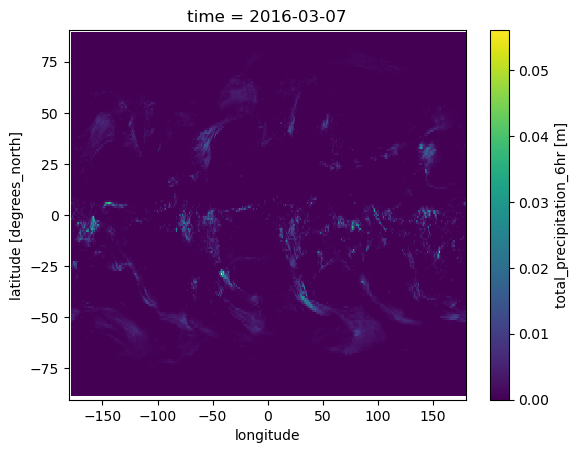

In [46]:
updated_era5.isel(time=1000)['total_precipitation_6hr'].plot()

In [198]:
imerg_regridded

<xarray.Dataset> Size: 192MB
Dimensions:        (time: 184, longitude: 360, latitude: 181)
Coordinates:
  * time           (time) datetime64[ns] 1kB 2015-07-01 ... 2015-12-31
    lat            (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
    lon            (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude       (latitude) float32 724B -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * longitude      (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    precipitation  (time, longitude, latitude) float64 96MB nan nan ... 0.0 nan
    randomError    (time, longitude, latitude) float64 96MB nan nan ... nan
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

In [ ]:
updated_era5.to_zarr('/Datastorage/saptarishi.dhanuka_asp25/era5_20150701_20220731_1deg_37levels_with_imerg.zarr')

KeyboardInterrupt: 

In [ ]:
updated_era5.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/era5_20150701_20220731_1deg_37levels_with_imerg.nc')

In [24]:
import matplotlib.pyplot as plt
print("Running validation tests...")

# 1. Create independent validation dataset from IMERG
# This will apply the same transformations separately so we can verify our merged results
validation_data = xr.Dataset(
    coords={
        "time": era5_times,
        "latitude": target_lat,
        "longitude": target_lon
    }
)

# Create a validation precipitation field using the same process
validation_data["precip_validation"] = imerg_6hr.precipitation_6hr.copy()

# 2. Test that our values match between validation_data and updated_era5
# Check if all values are equal
exact_match = np.array_equal(
    validation_data.precip_validation.values,
    updated_era5.total_precipitation_6hr.values
)

print(f"Exact value match: {exact_match}")

# Check for any differences
if not exact_match:
    diff = np.abs(validation_data.precip_validation - updated_era5.total_precipitation_6hr)
    max_diff = diff.max().values
    mean_diff = diff.mean().values
    print(f"Maximum difference: {max_diff}")
    print(f"Mean difference: {mean_diff}")
    
    # If differences are very small, they may be due to floating point precision
    if max_diff < 1e-10:
        print("Differences are within floating point precision - validation passed")
    else:
        print("WARNING: Significant differences found!")

# 3. Verify temporal consistency
# For each day, check that all 4 6-hourly periods have the same value
for day in pd.DatetimeIndex(era5_times.values).normalize().unique():
    next_day = day + pd.Timedelta(days=1)
    day_mask = (era5_times >= day) & (era5_times < next_day)
    day_data = updated_era5.total_precipitation_6hr.sel(time=day_mask)
    
    # If we have data for this day, check consistency across 6hr periods
    if len(day_data.time) > 1:
        first_period = day_data.isel(time=0)
        
        # Check if all other periods in this day match the first
        for i in range(1, len(day_data.time)):
            period_match = np.array_equal(first_period.values, day_data.isel(time=i).values)
            if not period_match:
                print(f"WARNING: Inconsistent 6hr periods found for day {day}")
                break

# 4. Verify spatial consistency with original IMERG
# For a sample day, compare the daily sum in updated_era5 with the original IMERG
sample_day = pd.DatetimeIndex(era5_times.values).normalize().unique()[10]  # Pick 10th day

# Get matching IMERG day
imerg_day = imerg_regridded.sel(time=sample_day)

# Sum the 4 six-hourly periods in updated_era5 for this day
day_mask = (era5_times >= sample_day) & (era5_times < sample_day + pd.Timedelta(days=1))
era5_day_sum = updated_era5.total_precipitation_6hr.sel(time=day_mask).sum(dim='time')

# Convert units: era5 is in m/6hr, need to convert to mm/day for comparison
# 4 periods × m/6hr × 1000 mm/m = mm/day
era5_day_mm = era5_day_sum * 1000

# Check that values are close (allowing for interpolation differences)
if 'precipitation' in imerg_day:
    max_diff_spatial = np.abs(era5_day_mm - imerg_day.precipitation).max().values
    print(f"Maximum spatial difference after conversion (mm/day): {max_diff_spatial}")
    
    # Plot sample comparison if differences are large
    if max_diff_spatial > 0.1:  # More than 0.1 mm/day difference
        plt.figure(figsize=(16, 5))
        
        plt.subplot(131)
        era5_day_mm.plot(cmap='Blues', title='Updated ERA5 (mm/day)')
        
        plt.subplot(132)
        imerg_day.precipitation.plot(cmap='Blues', title='Original IMERG (mm/day)')
        
        plt.subplot(133)
        np.abs(era5_day_mm - imerg_day.precipitation).plot(
            cmap='Reds', 
            title='Absolute Difference (mm/day)'
        )
        
        plt.tight_layout()
        plt.savefig('precipitation_validation.png')
        print("Validation plot saved to 'precipitation_validation.png'")

# 5. Verify unit consistency - spot check some values
# Pick a random location and time
random_time_idx = np.random.randint(0, len(era5_times))
random_lat_idx = np.random.randint(0, len(target_lat))
random_lon_idx = np.random.randint(0, len(target_lon))

random_time = era5_times[random_time_idx].values
random_lat = target_lat[random_lat_idx].values
random_lon = target_lon[random_lon_idx].values

# Get corresponding day
random_day = pd.Timestamp(random_time).normalize()

# Get values
era5_value = updated_era5.total_precipitation_6hr.sel(
    time=random_time, 
    latitude=random_lat, 
    longitude=random_lon
).values

imerg_day_value = imerg_regridded.sel(
    time=random_day,
    latitude=random_lat,
    longitude=random_lon
)

if 'precipitation' in imerg_day_value:
    imerg_original = imerg_day_value.precipitation.values  # mm/day
    expected_era5_value = imerg_original * 0.25 * 0.001  # convert to m/6hr
    
    print("\nSpot check validation:")
    print(f"Location: lat={random_lat}, lon={random_lon}, time={random_time}")
    print(f"IMERG value (mm/day): {imerg_original}")
    print(f"Expected ERA5 value (m/6hr): {expected_era5_value}")
    print(f"Actual ERA5 value (m/6hr): {era5_value}")
    print(f"Difference: {abs(expected_era5_value - era5_value)}")

print("\nValidation complete!")

# Save the updated ERA5 dataset
# updated_era5.to_netcdf('era5_with_imerg_precip.nc')

print("Successfully replaced ERA5 precipitation with IMERG data")

Running validation tests...
Exact value match: False
Maximum difference: 0.0
Mean difference: 0.0
Differences are within floating point precision - validation passed
Maximum spatial difference after conversion (mm/day): 5.684341886080802e-14

Spot check validation:
Location: lat=-83.0, lon=-42.0, time=2015-10-23T18:00:00.000000000
IMERG value (mm/day): 0.0
Expected ERA5 value (m/6hr): 0.0
Actual ERA5 value (m/6hr): 0.0
Difference: 0.0

Validation complete!
Successfully replaced ERA5 precipitation with IMERG data


In [120]:
%reset -f

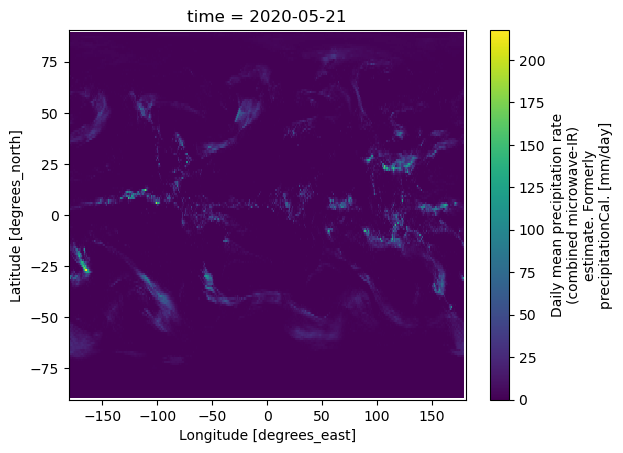

In [48]:
combined.isel(time=1).precipitation.plot(x='lon', y='lat', cmap='viridis')

need to keep in mind that imerg has a different lat lon system

In [1]:
%reset -f

In [ ]:
combined

In [15]:
imerg_india = imerg_test_interp.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))
imerg_india

<xarray.Dataset> Size: 74kB
Dimensions:                         (time: 1, lon: 31, lat: 33, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2024-09-29
  * lat                             (lat) float64 264B 38.0 37.0 ... 7.0 6.0
  * lon                             (lon) float64 248B 68.0 69.0 ... 97.0 98.0
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float64 8kB 0.8562 ... 0...
    precipitation_cnt               (time, lon, lat) float64 8kB 48.0 ... 48.0
    precipitation_cnt_cond          (time, lon, lat) float64 8kB 10.0 ... 6.0
    MWprecipitation                 (time, lon, lat) float64 8kB 0.5073 ... 2...
    MWprecipitation_cnt             (time, lon, lat) float64 8kB 11.0 ... 9.0
    MWprecipitation_cnt_cond        (time, lon, lat) float64 8kB 1.0 1.0 ... 1.0
    randomError                     (time, lon, lat) float64 8kB 34.22 ... 9.827
    randomError_cnt                 (time, lon, lat) float64 8kB 48.0 ... 48.0
    probabilityLiquidPrecipitation  (time, lon, lat) float64 8kB 100.0 ... 100.0
    time_bnds                       (time, nv) datetime64[ns] 16B 2024-09-29 ...
Attributes:
    BeginDate:       2024-09-29
    BeginTime:       00:00:00.000Z
    EndDate:         2024-09-29
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-09-29T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240929-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2025-01-28T21:50:39.390Z

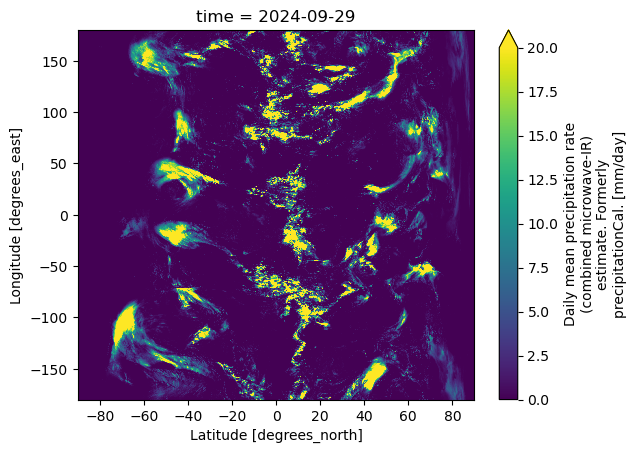

In [17]:
imerg_test.isel(time=0)['precipitation'].plot(cmap='viridis', vmin=0, vmax=20)